In [ ]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1
import matplotlib.pyplot as plt
import sys

from utils.io_utils import load_multiple_res
from utils.utils import get_path
from utils.pd_utils import get_persistent_feature_id, get_persistent_cycle, compute_outlier_scores, filter_diagram
from utils.toydata_utils import get_toy_data
from utils.fig_utils import full_dist_to_color, all_full_dists, dist_to_color, full_dist_to_print, plot_edges_on_scatter

from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict
from persim import plot_diagrams
import os
import numpy as np
from sklearn.decomposition import PCA
import pickle

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [566]:
dataset = "tasic_orange"

style_file = "utils.style"
plt.style.use(style_file)

root_path = get_path("data")
fig_path = get_path("figures")

distances = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [567]:
all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)


Done with tasic_orange None euclidean n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


In [569]:
def plot_diagrams_alpha(
    diagrams,
    color,
    alpha,
    size=20,
    ax=None
): # change over persim.plot_diagrams

    ax = ax or plt.gca()
    plt.style.use("default")

    if not isinstance(diagrams, list):
        diagrams = [diagrams]

    # Construct copy with proper type of each diagram
    # so we can freely edit them.
    diagrams = [dgm.astype(np.float32, copy=True) for dgm in diagrams]

    concat_dgms = np.concatenate(diagrams).flatten()
    has_inf = np.any(np.isinf(concat_dgms))
    finite_dgms = concat_dgms[np.isfinite(concat_dgms)]
    ax_min, ax_max = np.min(finite_dgms), np.max(finite_dgms)
    x_r = ax_max - ax_min
    buffer = x_r / 5
    x_down = ax_min - buffer / 2
    x_up = ax_max + buffer
    y_down, y_up = x_down, x_up

    yr = y_up - y_down

    # Plot diagonal
    ax.plot([x_down, x_up], [x_down, x_up], "--", c = np.array([0.7, 0.7, 0.7]))

    if has_inf:
        b_inf = y_down + yr * 0.95
        ax.plot([x_down, x_up], [b_inf, b_inf], "--", c="k", label=r"$\infty$")
        for dgm in diagrams:
            dgm[np.isinf(dgm)] = b_inf

    for dgm in diagrams:
        ax.scatter(dgm[:, 0], dgm[:, 1], size, color = color, alpha = alpha, edgecolor="none")

    ax.set_xlim([x_down, x_up])
    ax.set_ylim([y_down, y_up])
    ax.set_aspect('equal', 'box')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


In [570]:

#stopped here ,didnt debug....
life_time = reference_dgm["dgms"][1][:, 1] - reference_dgm["dgms"][1][:, 0]
quarter_threshold = np.percentile(life_time, 75)

idx = next(i for i, x in enumerate(life_time) if x > quarter_threshold)
selected_ref = reference_dgm["dgms"][1][idx,:]
n_loops = len(selected_ref)

## but i dont think this plot is working??? i mean it doesnt really show the pair up or smth....

Text(0.5, 0.98, 'tasic_orange, diffusion_k_15_t_8_kernel_sknn_include_self_False, pd of shuffled_pts')

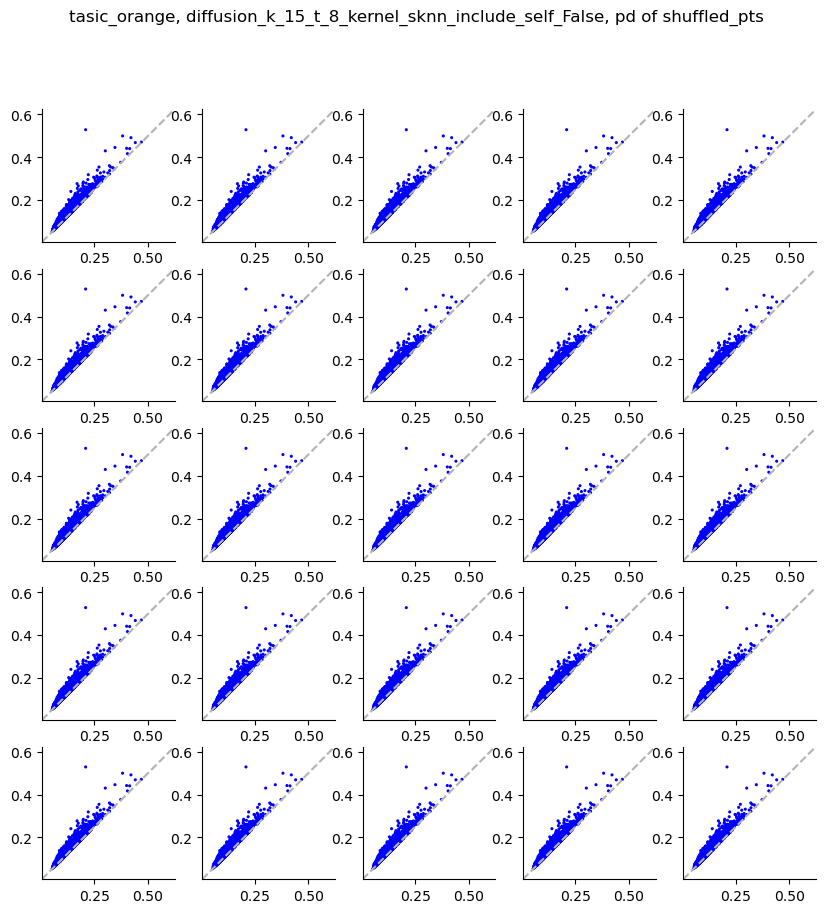

In [575]:

# for i, distance in enumerate(all_res.keys()):
#     for j, full_dist in enumerate(all_res[distance]):
distance = "diffusion"
full_dist = "diffusion_k_15_t_8_kernel_sknn_include_self_False"
reference_dgm = all_res[distance][full_dist]

fig, axs = plt.subplots(5, 5, figsize=(10, 10))
for r, ax in enumerate(axs.flat):
    file_name = os.path.join(root_path,
        dataset,
        f"{dataset}_seed_0_shuffle_pts_{r}_{full_dist}_rep")
    # repeated_dgm = read_ripser_result(file_name)
    plot_diagrams_alpha(repeated_dgm["dgms"][1], ax=ax, size=5, color = "blue", alpha = 1)
    
    
    # plot_diagrams_alpha(reference_dgm["dgms"][1], ax=ax, size=5, color = "blue", alpha = 1)
    #  reference_dgm["dgms"][1]
fig.suptitle(f"{dataset}, {full_dist}, pd of shuffled_pts")
# fig.savefig(os.path.join(fig_path, f"{dataset}_{distance}_{full_dist}_repeated_dgms.png"))


## So im thinking the diagram plots thingy doesnt really work….im investigating on the matching,,,,so basically redo the bottleneck of shuffle_pts, and return_matches = true.


In [698]:
trytry = load_dict(os.path.join(root_path, "tasic_orange/bottleneck_match_shuffle_pts_quarter_diffusion_k_15_t_8_kernel_sknn_include_self_False.pkl"))

In [699]:
trytry.keys()

dict_keys(['bottleneck', 'matching'])

In [706]:
trytry["matching"]

[array([[ 0.0000000e+00,  6.0000000e+01,  5.6272530e-01],
        [ 1.0000000e+00,  3.1300000e+02,  8.8898050e-01],
        [ 2.0000000e+00,  4.2000000e+02,  1.1158908e+00],
        ...,
        [-1.0000000e+00,  5.2900000e+02,  1.1346385e+00],
        [-1.0000000e+00,  5.3000000e+02,  5.8256000e-01],
        [-1.0000000e+00,  5.3100000e+02,  1.2083500e-01]]),
 array([[ 0.0000000e+00,  6.0000000e+01,  5.6296730e-01],
        [ 1.0000000e+00,  3.1300000e+02,  8.8807200e-01],
        [ 2.0000000e+00,  4.2000000e+02,  1.1154615e+00],
        ...,
        [-1.0000000e+00,  5.2900000e+02,  1.1346385e+00],
        [-1.0000000e+00,  5.3000000e+02,  5.8256000e-01],
        [-1.0000000e+00,  5.3100000e+02,  1.2083500e-01]]),
 array([[ 0.0000000e+00,  6.0000000e+01,  5.6759790e-01],
        [ 1.0000000e+00,  3.1300000e+02,  8.9476200e-01],
        [ 2.0000000e+00,  4.2000000e+02,  1.1212880e+00],
        ...,
        [-1.0000000e+00,  5.2900000e+02,  1.1346385e+00],
        [-1.0000000e+00,  5.3

In [517]:
trytry["bottleneck"]

array([1.1346385, 1.1346385, 1.1346385, 1.1346385, 1.1346385, 1.1346385,
       1.1346385, 1.1346385, 1.1346385, 1.1346385, 1.1346385, 1.1346385,
       1.1346385, 1.1346385, 1.1346385, 1.1346385, 1.1346385, 1.1346385,
       1.1346385, 1.1346385, 1.1346385, 1.1346385, 1.1346385, 1.1346385,
       1.1346385])

In [660]:
np.argmax(trytry['matching'][0][:,2])

648

In [707]:
np.max(trytry['matching'][0][:,2])

1.1346384999999999

In [658]:
print(trytry['matching'][0][550:,:])


[[-1.0000000e+00  3.0200000e+02  1.9675700e-01]
 [-1.0000000e+00  3.0600000e+02  8.1461500e-02]
 [-1.0000000e+00  3.1000000e+02  1.0858800e-01]
 [-1.0000000e+00  3.1200000e+02  1.2062700e-01]
 [-1.0000000e+00  3.1700000e+02  2.2005650e-01]
 [-1.0000000e+00  3.2000000e+02  7.9385000e-02]
 [-1.0000000e+00  3.2400000e+02  9.1232500e-02]
 [-1.0000000e+00  3.2600000e+02  1.3345750e-01]
 [-1.0000000e+00  3.2700000e+02  1.3130150e-01]
 [-1.0000000e+00  3.3100000e+02  1.5240000e-01]
 [-1.0000000e+00  3.3200000e+02  6.3582500e-02]
 [-1.0000000e+00  3.4000000e+02  7.4312500e-02]
 [-1.0000000e+00  3.4200000e+02  6.9600500e-02]
 [-1.0000000e+00  3.4400000e+02  9.0954500e-02]
 [-1.0000000e+00  3.4800000e+02  7.5333500e-02]
 [-1.0000000e+00  3.5000000e+02  2.0471250e-01]
 [-1.0000000e+00  3.5100000e+02  1.0031150e-01]
 [-1.0000000e+00  3.5500000e+02  1.0687950e-01]
 [-1.0000000e+00  3.5800000e+02  9.1504000e-02]
 [-1.0000000e+00  3.6000000e+02  6.3649000e-02]
 [-1.0000000e+00  3.6100000e+02  1.46310

# I REALLY DONT UNDERSTAND....

In [ ]:
for r in range(25):
    idx = np.argmax(trytry['matching'][r][:,2])

    print(trytry['matching'][r][idx,:])

[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]
[ -1.        529.          1.1346385]


In [ ]:
the_threshold = int(np.floor(len(reference_life_long)/4))
distance = "diffusion"
full_dist = "diffusion_k_15_t_8_kernel_sknn_include_self_False"
filtered_ref_dgm, max_del_lt = filter_diagram(all_res[distance][full_dist], dim=1,  n=the_threshold)


file_name = os.path.join(root_path,
        dataset,
        f"{dataset}_seed_0_shuffle_pts_0_{full_dist}_rep")
repeated_dgm = read_ripser_result(file_name)
# plot_diagrams_alpha(repeated_dgm["dgms"][1], ax=ax, size=5, color = "blue", alpha = 1)
filtered_dgm, max_del_lts = filter_diagram(repeated_dgm, dim=1, n=the_threshold)

In [552]:
filtered_ref_dgm["dgms"][1][529,:]

array([0.763643, 3.03292 ])

In [553]:
lifetime = filtered_ref_dgm["dgms"][1][:,1] - filtered_ref_dgm["dgms"][1][:,0]

In [554]:
np.argmax(lifetime)

529

In [577]:
max_del_lt

0.12474600000000002

In [673]:
(3.03292 - 0.763643)/2

1.1346384999999999

# so the conclusion here is that, the most persistent dot in orignal data always match with sm point at the diagnal, and it happens to be the largest distance, thus become the bottleneck distance....


# but as S asked, this cant explain, why there's still outliers...if its true, then no loop could be included...

In [579]:
distance = "diffusion"
full_dist = "diffusion_k_15_t_8_kernel_sknn_include_self_False"
filtered_ref_dgm, max_del_lt = filter_diagram(all_res[distance][full_dist], dim=1,  n=the_threshold)


file_name = os.path.join(root_path,
        dataset,
        f"{dataset}_seed_0_shuffle_pts_0_{full_dist}_rep")
repeated_dgm = read_ripser_result(file_name)
# plot_diagrams_alpha(repeated_dgm["dgms"][1], ax=ax, size=5, color = "blue", alpha = 1)
filtered_dgm, max_del_lts = filter_diagram(repeated_dgm, dim=1, n=the_threshold)

In [585]:
filtered_ref_dgm['dgms'][0].shape

(5113, 2)

In [586]:
filtered_dgm['dgms'][0].shape

(5113, 2)

In [611]:
from bisect import bisect_left
from hopcroftkarp import HopcroftKarp

In [ ]:

dgm1 = filtered_ref_dgm['dgms'][1]
dgm2 = filtered_dgm['dgms'][1]

S = np.array(dgm1)
M = min(S.shape[0], S.size)
if S.size > 0:
    S = S[np.isfinite(S[:, 1]), :]
T = np.array(dgm2)
N = min(T.shape[0], T.size)
if T.size > 0:
    T = T[np.isfinite(T[:, 1]), :]

# Step 1: Compute CSM between S and T, including points on diagonal
# L Infinity distance
Sb, Sd = S[:, 0], S[:, 1]
Tb, Td = T[:, 0], T[:, 1]
D1 = np.abs(Sb[:, None] - Tb[None, :])
D2 = np.abs(Sd[:, None] - Td[None, :])
DUL = np.maximum(D1, D2)

D = np.zeros((M + N, M + N))
D[0:M, 0:N] = DUL
UR = np.inf * np.ones((M, M))
np.fill_diagonal(UR, 0.5 * (S[:, 1] - S[:, 0]))
D[0:M, N::] = UR
UL = np.inf * np.ones((N, N))
np.fill_diagonal(UL, 0.5 * (T[:, 1] - T[:, 0]))
D[M::, 0:N] = UL

# Step 2: Perform a binary search + Hopcroft Karp to find the
# bottleneck distance
ds = np.sort(np.unique(D.flatten()))  #[0:-1]  # Everything but np.inf
bdist = ds[-1]

matching = {}
while len(ds) >= 1:
    idx = 0
    if len(ds) > 1:
        idx = bisect_left(range(ds.size), int(ds.size / 2))
    # basically idx is the half..
    d = ds[idx]
    graph = {}
    for i in range(D.shape[0]):
        graph["{}".format(i)] = {j for j in range(D.shape[1]) if D[i, j] <= d}
    # print(len(graph.keys())) always 1064 
    res = HopcroftKarp(graph).maximum_matching()
    print(f"d = {d}")
    print(f"bdist = {bdist}")
    if len(res) == 2 * D.shape[0] and d <= bdist:
        print(f"update!, bdist = {d}")
        bdist = d
        matching = res
        ds = ds[0:idx]
    else:
        ds = ds[idx + 1 : :]
    



d = 0.732232
bdist = inf
d = 0.9832859999999999
bdist = inf
d = 1.221024
bdist = inf
update!, bdist = 1.221024
d = 1.0861910000000001
bdist = 1.221024
d = 1.1450179999999999
bdist = 1.221024
update!, bdist = 1.1450179999999999
d = 1.113648
bdist = 1.1450179999999999
d = 1.128495
bdist = 1.1450179999999999
d = 1.136602
bdist = 1.1450179999999999
update!, bdist = 1.136602
d = 1.132562
bdist = 1.136602
d = 1.134531
bdist = 1.136602
d = 1.135574
bdist = 1.136602
update!, bdist = 1.135574
d = 1.135017
bdist = 1.135574
update!, bdist = 1.135017
d = 1.134749
bdist = 1.135017
update!, bdist = 1.134749
d = 1.134632
bdist = 1.134749
d = 1.1346930000000002
bdist = 1.134749
update!, bdist = 1.1346930000000002
d = 1.1346530000000001
bdist = 1.1346930000000002
update!, bdist = 1.1346530000000001
d = 1.134644
bdist = 1.1346530000000001
update!, bdist = 1.134644
d = 1.1346384999999999
bdist = 1.134644
update!, bdist = 1.1346384999999999


In [ ]:
sum(np.isinf(D))

array([531, 531, 531, ..., 531, 531, 531])

In [ ]:
matchidx = []
for i in range(M + N):
    j = matching["{}".format(i)]
    d = D[i, j]
    if i < M:
        if j >= N:
            j = -1  # Diagonal match from first persistence diagram
    else:
        if j >= N:  # Diagonal to diagonal, so don't include this
            continue
        i = -1
    matchidx.append([i, j, d])
 np.array(matchidx)

In [664]:
ds = np.sort(np.unique(D.flatten()))[0:-1]  # Everything but np.inf
np.max(ds)

3.0540843000000004

In [668]:
M

532

In [672]:
D[:532, 529]

array([0.12005 , 0.090538, 0.100056, 0.12854 , 0.087041, 0.086236,
       0.052727, 0.060887, 0.040616, 0.045053, 0.089408, 0.104113,
       0.070211, 0.049842, 0.055971, 0.05619 , 0.059887, 0.064551,
       0.066697, 0.070525, 0.0889  , 0.096725, 0.08166 , 0.084174,
       0.084332, 0.084687, 0.089963, 0.092766, 0.093014, 0.09498 ,
       0.097877, 0.1004  , 0.100964, 0.104064, 0.107046, 0.109776,
       0.11177 , 0.111788, 0.11219 , 0.112316, 0.113643, 0.115258,
       0.117226, 0.121138, 0.123941, 0.126285, 0.127282, 0.128904,
       0.12937 , 0.131789, 0.134498, 0.135675, 0.1378  , 0.138475,
       0.139659, 0.141227, 0.141907, 0.142356, 0.142859, 0.143504,
       0.144629, 0.146876, 0.147171, 0.147897, 0.151526, 0.151887,
       0.15229 , 0.153398, 0.153453, 0.153552, 0.153761, 0.156391,
       0.156771, 0.156986, 0.158448, 0.158593, 0.160572, 0.160926,
       0.163131, 0.163819, 0.164056, 0.167806, 0.168012, 0.169631,
       0.170667, 0.171535, 0.171599, 0.172654, 0.173919, 0.174

In [671]:
D[529, :532]

array([2.9402143, 2.9383095, 2.9365408, 2.9361495, 2.935732 , 2.9357137,
       2.9348094, 2.9342631, 2.9342335, 2.9342218, 2.9337771, 2.9335816,
       2.932441 , 2.932143 , 2.931131 , 2.930793 , 2.930274 , 2.930222 ,
       2.929715 , 2.929683 , 2.92916  , 2.928806 , 2.92864  , 2.928135 ,
       2.927962 , 2.927832 , 2.927831 , 2.924906 , 2.924514 , 2.923913 ,
       2.923872 , 2.923602 , 2.922879 , 2.92261  , 2.922287 , 2.921355 ,
       2.921233 , 2.920764 , 2.920068 , 2.920009 , 2.919756 , 2.919716 ,
       2.919171 , 2.918923 , 2.918587 , 2.917984 , 2.917979 , 2.917929 ,
       2.917623 , 2.917493 , 2.917279 , 2.917118 , 2.916995 , 2.916655 ,
       2.916371 , 2.915952 , 2.915869 , 2.915837 , 2.915741 , 2.91547  ,
       2.915425 , 2.915133 , 2.914974 , 2.914719 , 2.914449 , 2.91391  ,
       2.91369  , 2.913273 , 2.913254 , 2.913242 , 2.913007 , 2.912946 ,
       2.91239  , 2.912387 , 2.912046 , 2.912004 , 2.911894 , 2.91174  ,
       2.911532 , 2.911152 , 2.911099 , 2.910717 , 